In [100]:
import time
from typing import List
import numpy as np
import torch
import torch.nn as nn
import torchode
from pathlib import Path
import pickle

from scipy.integrate import solve_ivp as sp_solve_ivp
from tqdm.auto import tqdm
from scipy.optimize import root as sp_root

from sklearn.preprocessing import MinMaxScaler
from ftnode.utils import set_global_seed, _load_loop_wrapper
from ftnode.node import (
    FTNODE, FeluSigmoidMLP,FeluSigmoidMLPfeaturized,
     GeluSigmoidMLPfeaturized,
)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.family']= 'serif'

device = 'cpu'
seed = 1234
set_global_seed(seed=seed)

[Seed] Deterministic mode enabled (may reduce speed).


In [101]:
def hysteresis_ode(t,x,lam):
    return lam+x-x**3

n_lam = 51
n_traj = 51
lams = np.linspace(-1,1,n_lam)
xs = np.linspace(-2,2,n_traj)


t_max = 0.25
n_colloc = 101


Xs = []
Us = []
t = np.linspace(0,t_max,n_colloc)
for lami in tqdm(lams):
    for x0 in xs:
        sol = sp_solve_ivp(
            hysteresis_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (lami,)
        )

        Xs.append(sol.y.T)
        Us.append([lami])
Xs = np.array(Xs)
Us = np.array(Us)

scaler = MinMaxScaler(feature_range=(-1,1))
scaler.fit(Xs.reshape(-1,1).reshape(-1,1))

  0%|          | 0/51 [00:00<?, ?it/s]

,feature_range,"(-1, ...)"
,copy,True
,clip,False


In [102]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims=[1,20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=-0.1,
    init_type=None
)


g = GeluSigmoidMLPfeaturized(
    dims=[6, 20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-2,
    upper_bound=2,
    freq_sample_step=1,
    feat_lower_bound=-1.5,
    feat_upper_bound=1.5,
    init_type=None
)

model = FTNODE(f, g).to(device)
model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()

GeluSigmoidMLPfeaturized(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

In [103]:
def R(u,x,k, x_target):
    for _ in range(k):
        x = g(x, u)
    return x - x_target

def u_prime(u,x,x_target,eta,k):
    u = torch.tensor(u,dtype=torch.float32, requires_grad=True)
    x = torch.tensor(x,dtype=torch.float32, requires_grad=False)
    x_target = torch.tensor(x_target,dtype=torch.float32, requires_grad=False)
    resid = torch.sum(R(u,x,k,x_target)**2)
    resid.backward()

    grad = u.grad.numpy()
    return -eta*grad

def hysteresis_ode_control(t,xu,x_target,eta,k):
    x = xu[:1]
    u = xu[1:]
    x_scaled = scaler.transform(x.reshape(-1,1)).reshape(-1)
    x_target_scaled = scaler.transform(x_target.reshape(-1,1)).reshape(-1)

    dxdt = hysteresis_ode(t,x,u)
    dudt = u_prime(u,x_scaled,x_target_scaled, eta,k)

    return np.hstack([dxdt,dudt])


def make_drift(x_target, scaler, eta, k):
    """
    Drift for SDE: d[x,u]^T = drift(x,u,t)*dt + diffusion(x,u,t)*dW
    """

    def drift(xu, t):
        x = xu[0]
        u = xu[1]


        x_scaled = scaler.transform(np.array([[x]]))
        x_target_scaled = scaler.transform(np.array([[x_target]]))
        

        dxdt = hysteresis_ode(t, x, u)
        u = np.array([[u]])

        dudt = u_prime(u, x_scaled, x_target_scaled, eta, k)[0,0]

        return np.array([dxdt, dudt])

    return drift

def scalar_noise(x, scale=0.01):
    """
    Example multiplicative noise for scalar system.
    """
    sig = scale * np.sqrt(abs(x))
    return sig

def make_diffusion(scale):
    """
    Diffusion matrix G(x) for SDE:
        d[x,u]^T = drift dt + G dW
    G : (2 × 1) matrix in scalar case
    """

    def diffusion(xu, t):
        x = xu[0]
        sig = scalar_noise(x, scale)

        G = np.zeros((2, 1))
        G[0, 0] = sig   
        return G

    return diffusion



In [104]:
seed = 67
rng = np.random.default_rng(seed=seed)

n_targets = 15

x_targets = []
for idx in range(n_targets):
    x_targets.append(rng.uniform(-1.5,1.5))

In [105]:
t_max = 5
n_colloc = 101
eta = 5e0
k = 1

xu0 = np.array([1,1])



Ts = []
Xs = []
Us = []
Xs_targets = []

for x_target in tqdm(x_targets):
    x_target = np.array(x_target)
    sol = sp_solve_ivp(
        hysteresis_ode_control,
        t_span = [0,t_max],
        y0 = xu0,
        t_eval = np.linspace(0,t_max, n_colloc),
        args = (x_target,eta,k)
    )

    XU = sol.y
    X = XU[0,:]
    U = XU[1,:]
    xu0 = sol.y[:,-1]

    Ts.append(sol.t)
    Xs.append(X)
    Us.append(U)
    Xs_targets.append(x_target)

  0%|          | 0/15 [00:00<?, ?it/s]

In [106]:
Gs = []
for i in tqdm(range(len(Us))):
    ui = Us[i]
    xi=Xs[i]
    
    xi_scaled_tensor = torch.tensor(scaler.transform(xi.reshape(-1,1)),dtype=torch.float32)
    ui_tensor = torch.tensor(ui.reshape(-1,1), dtype=torch.float32)
    with torch.no_grad():
        gi = g(xi_scaled_tensor, ui_tensor)
    
    gi_unscaled = scaler.inverse_transform(gi).reshape(-1)
    Gs.append(gi_unscaled)
    
T_tot = np.linspace(0,t_max*n_targets,n_colloc*n_targets)
G_tot = np.concatenate(Gs)

  0%|          | 0/15 [00:00<?, ?it/s]

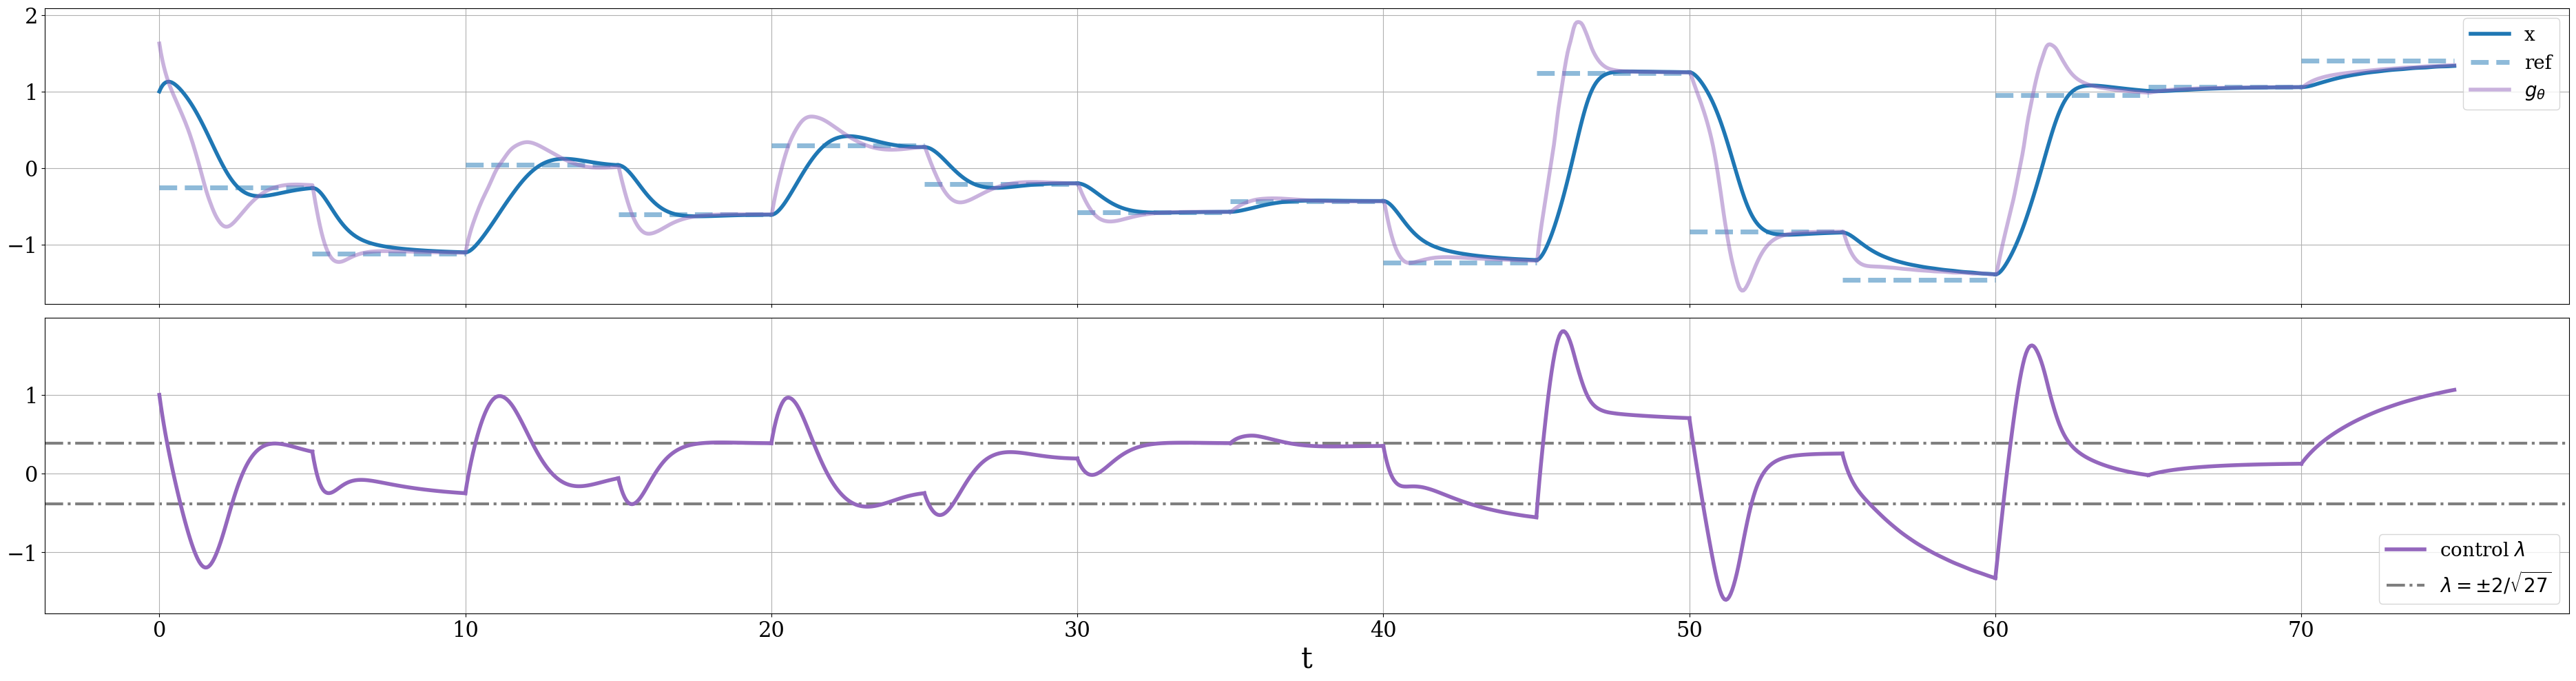

In [107]:
lw=4

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(2.5*n_targets, 10),sharex=True)

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Usi = Us[idx]
    Xsi = Xs[idx]
    Xsi_target = Xs_targets[idx]
    Gsi = Gs[idx]

    tank1_label = None
    tank2_label = None

    tar1_label = None
    tar2_label = None

    g_label = None

    if idx == 0:
        tank1_label = "x"
        tank2_label = "Tank 2"

        tar1_label="ref"
        tar2_label="ref 2"
        g_label = r"$g_\theta$"


    ax1.plot(ti, Xsi,c='tab:blue',lw=lw,label=tank1_label)
    # ax1.plot(ti,Gsi,c='tab:purple',lw=lw,label = g_label,alpha=0.8)
    # ax1.plot(ti, Xsi[1,:],c='tab:red',lw=lw,label=tank2_label)
    ax1.hlines(
        Xsi_target,
        xmin=ti[0],
        xmax=ti[-1],
        color='tab:blue',
        linestyle='--',
        alpha=0.5,
        lw=lw+1,
        label=tar1_label
        )


    

    p_label=None
    v_label = None
    if idx ==0:
        p_label = r"control $\lambda$"
        v_label = "Valve Opening"


    ax2.plot(ti,Usi,c='tab:purple',lw=lw,label=p_label)

    ax2.set_xlabel("t",size=30)

    ax2.legend(fontsize=20)

for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=18)

ax1.plot(T_tot,G_tot,c='tab:purple',lw=lw,label = r"$g_\theta$",alpha=0.5)
ax1.legend(fontsize=20)
ax2.axhline(np.sqrt(4/27),zorder=1,c='black',linestyle='-.',alpha=0.5,lw=3,label=r"$\lambda = \pm 2/\sqrt{27}$")
ax2.axhline(-np.sqrt(4/27),zorder=1,c='black',linestyle='-.',alpha=0.5,lw=3)
ax2.legend(fontsize=20)
ax1.grid(True)
ax2.grid(True)

plt.tight_layout()
plt.show()

# Stochastic Targets

In [108]:
def itoint(drift_func, diff_func, y0, t_span, dW):
    """
    A simple Euler-Maruyama solver that accepts pre-generated noise.
    
    Args:
        drift_func: Function f(y, t) returning (d,)
        diff_func:  Function G(y, t) returning (d, m)
        y0:         Initial state (d,)
        t_span:     Time array (N,)
        dW:         Pre-calculated noise increments (N-1, m)
    
    Returns:
        Solution array of shape (N, d)
    """
    N = len(t_span)
    d = len(y0)
    
    # Pre-allocate solution array
    ys = np.zeros((N, d))
    ys[0] = y0
    
    curr_y = y0.copy()
    
    for i in range(N - 1):
        t = t_span[i]
        dt = t_span[i+1] - t
        
        # Get the specific noise increment for this step
        dw_step = dW[i]  # Shape (2,)
        
        # Evaluate dynamics
        f = drift_func(curr_y, t)   # Shape (6,)
        G = diff_func(curr_y, t)    # Shape (6, 2)
        
        # Euler-Maruyama Step: y += f*dt + G*dW
        # matrix multiplication: (6,2) @ (2,) -> (6,)
        diffusion_step = G @ dw_step 
        
        curr_y = curr_y + f * dt + diffusion_step
        # curr_y[:2] = np.maximum(curr_y[:2], 0)
        ys[i+1] = curr_y
        
    return ys

In [109]:
seed = 3
seed = 2
np.random.seed(seed)
rng = np.random.default_rng(seed=seed)

torch.manual_seed(seed)

torch.use_deterministic_algorithms(True)



n_targets = 10


x_targets = []
for idx in range(n_targets):
    x_targets.append(rng.uniform(-1.5,1.5))


t_max = 10
n_colloc = 501
eta=5e0
k=1
scale = 0.05

t_span = np.linspace(0,t_max, n_colloc)
dt = t_span[1] - t_span[0]


xu0 = np.array([1,1])


Ts = []
Xs = []
Us = []
Xs_targets = []


noise_rng = np.random.default_rng(seed=seed)

for x_target in tqdm(x_targets):
    drift_term = make_drift(x_target,scaler,eta,k)
    diffusion_term = make_diffusion(scale)
    dW = noise_rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_colloc-1, 1))

    sto_sol = itoint(drift_term,diffusion_term,xu0,t_span,dW=dW)
    X = sto_sol[:,0]
    U = sto_sol[:,1]
    xu0 = sto_sol[-1]

    Ts.append(t_span)
    Xs.append(X)
    Us.append(U)
    Xs_targets.append(x_target)

Gs = []
for i in tqdm(range(len(Us))):
    ui = Us[i]
    xi=Xs[i]
    
    xi_scaled_tensor = torch.tensor(scaler.transform(xi.reshape(-1,1)),dtype=torch.float32)
    ui_tensor = torch.tensor(ui.reshape(-1,1), dtype=torch.float32)
    with torch.no_grad():
        gi = g(xi_scaled_tensor, ui_tensor)
    
    gi_unscaled = scaler.inverse_transform(gi).reshape(-1)
    Gs.append(gi_unscaled)
    
T_tot = np.linspace(0,t_max*n_targets,n_colloc*n_targets)
G_tot = np.concatenate(Gs)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

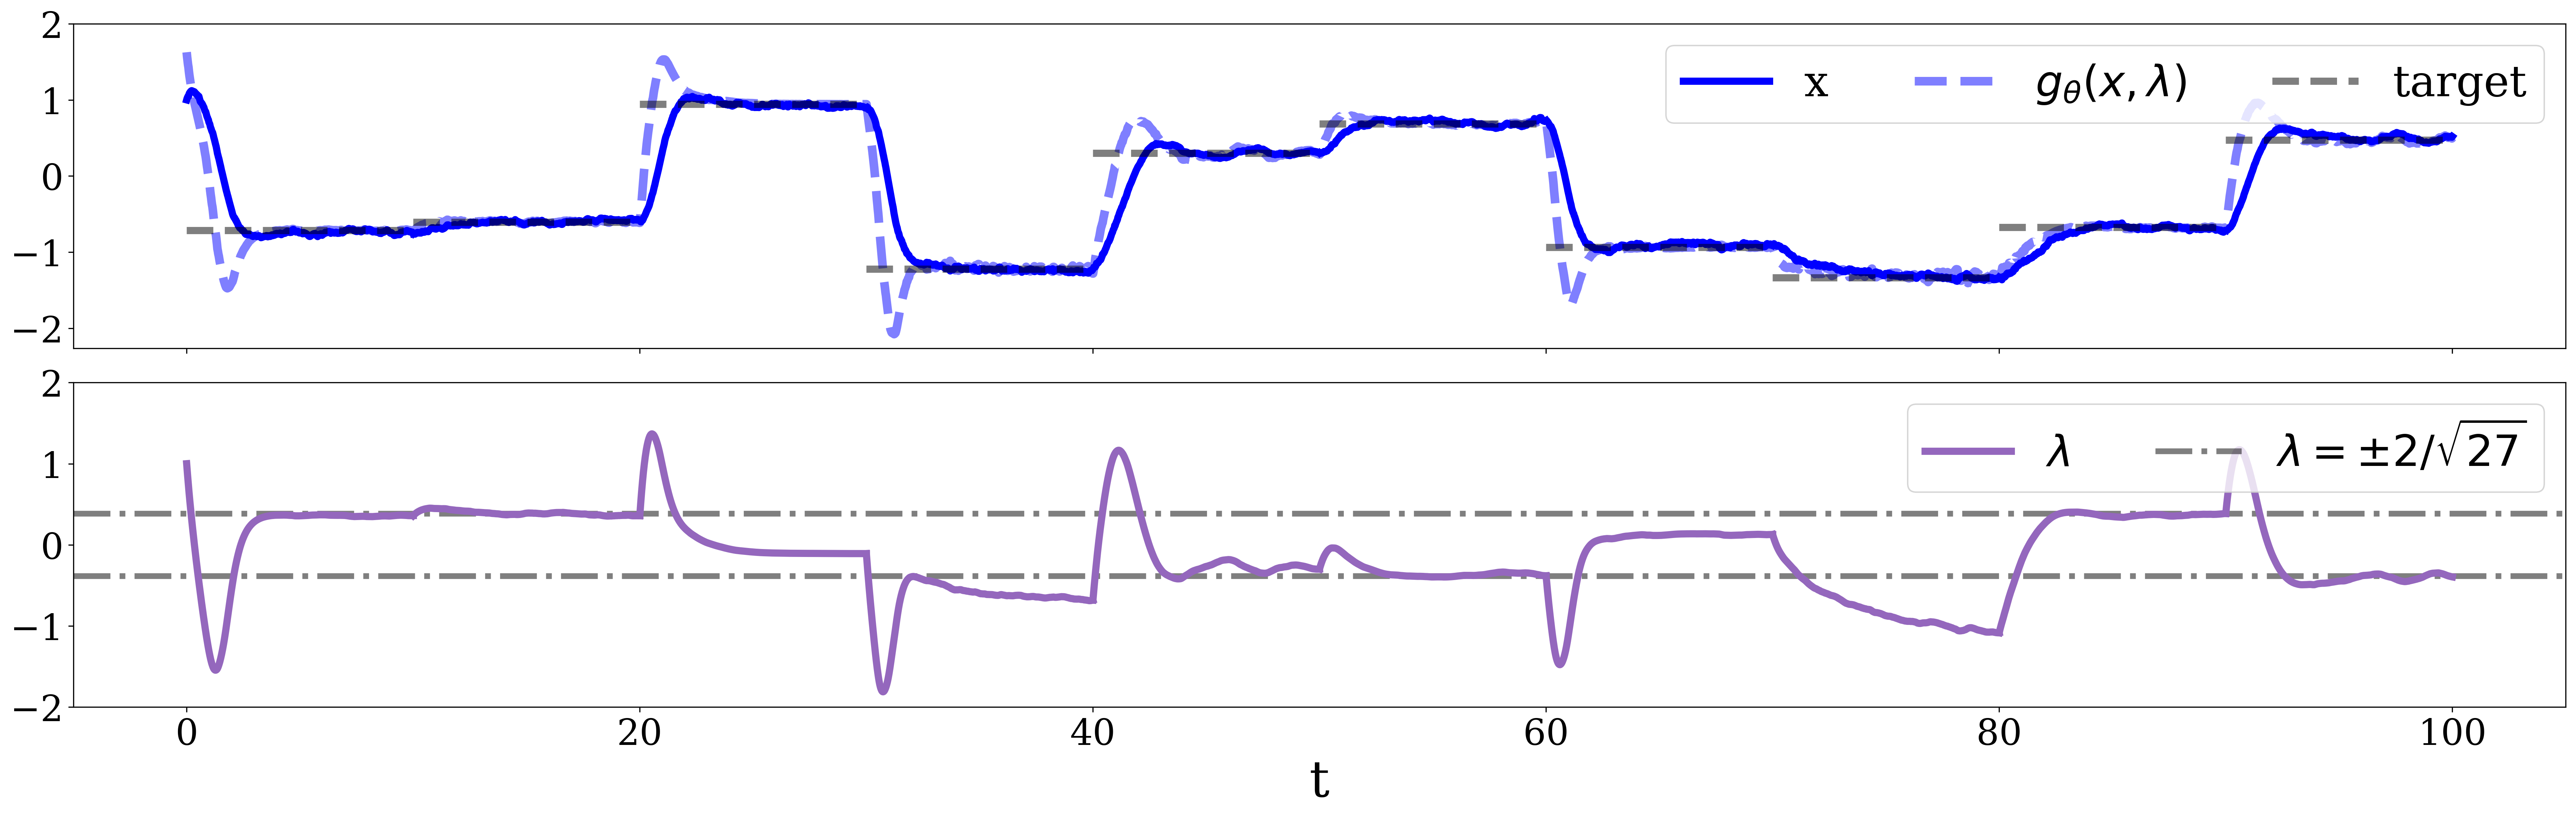

In [116]:
# Ts = [tspan for i in range(n_targets)]
lw=4

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(25, 8),sharex=True,dpi=300)

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Usi = Us[idx]
    Xsi = Xs[idx]
    Xsi_target = Xs_targets[idx]
    Gsi = Gs[idx]

    tank1_label = None
    tank2_label = None

    tar1_label = None
    tar2_label = None

    g_label = None

    if idx == 0:
        tank1_label = "x"
        tank2_label = "Tank 2"

        tar1_label="target"
        tar2_label="ref 2"
        g_label = r"$g_\theta(x,y)$"


    ax1.plot(ti, Xsi,c='blue',lw=lw+1,label=tank1_label)



    

    p_label=None
    v_label = None
    if idx ==0:
        p_label = r"$\lambda$"
        v_label = "Valve Opening"


    ax2.plot(ti,Usi,c='tab:purple',lw=lw+1,label=p_label)

    ax2.set_xlabel("t",size=35)

    # ax2.legend(fontsize=30)



ax1.plot(T_tot,G_tot,c='blue',linestyle='--',lw=lw+2,label = r"$g_\theta(x,\lambda)$",alpha=0.5)

for idx in range(len(Ts)):
    ti = Ts[idx] + idx*t_max
    Xsi_target = Xs_targets[idx]
    label = None

    if idx == 0:
        label="target"

    ax1.hlines(
        Xsi_target,
        xmin=ti[0],
        xmax=ti[-1],
        color='black',
        linestyle='--',
        alpha=0.5,
        lw=lw+1,
        label=label
        )
bbox_to_anchor=(1,1.4)
bbox_to_anchor=None
ax1.legend(fontsize=30,ncols=3,loc = 'upper right', bbox_to_anchor=bbox_to_anchor)
ax2.axhline(np.sqrt(4/27),zorder=1,c='black',linestyle='-.',alpha=0.5,lw=4,label=r"$\lambda = \pm 2/\sqrt{27}$")
ax2.axhline(-np.sqrt(4/27),zorder=1,c='black',linestyle='-.',alpha=0.5,lw=4)
loc = 'upper center'
# loc = 'upper right'
bbox_to_anchor = None
ax2.legend(fontsize=30,ncols=2,bbox_to_anchor = bbox_to_anchor)

for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='major', labelsize=25)
    ax.set_yticks([-2,-1,0,1,2])
    # ax.tick_params(axis='both', which='minor', labelsize=20)

plt.tight_layout()
plt.savefig("hysteresis-feedback-control.png")
plt.show()

# Multiple Seed Experiment 

In [174]:
Xs = []
Xs_targets = []
errs = []
vars = []
stds = []

settling_ratio = 0.2 # Look at last 20% of the trajectory
n_colloc = 501
t_max = 10
eta=5e0
k=1
t_span = np.linspace(0,t_max,n_colloc)
scale = 0.03
dt = t_span[1]-t_span[0]


t = np.linspace(0,1000,501)
seeds = [i for i in range(100)]

for seed in tqdm(seeds,unit="trial"):
    # print("Seed:", seed)
    rng = np.random.default_rng(seed)
    noise_rng = np.random.default_rng(seed)
    xu0 = np.array([1,1])


    for idx in range(n_targets,):
        # print("case:", idx)
        x_target = np.array(rng.uniform(-1.5,1.5))
        
        drift_term = make_drift(x_target,scaler,eta,k)
        diffusion_term = make_diffusion(scale)
        dW = noise_rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_colloc-1, 1))

        sto_sol = itoint(drift_term,diffusion_term,xu0,t_span,dW=dW)
        X = sto_sol[:,0]
        U = sto_sol[:,1]
        xu0 = sto_sol[-1]

        # Ts.append(t_span)
        Xs.append(X)
        # Us.append(U)
        Xs_targets.append(x_target)

        # get error and var
        n_steps = len(X)
        start_idx = int(n_steps * (1 - settling_ratio))
        steady_state = X[start_idx:]

        diff = np.abs(steady_state - x_target)
        err = np.linalg.norm(diff, axis=0) / np.sqrt(len(steady_state))
        var = np.var(diff,axis=0)
        stds.append(np.std(steady_state,axis=0))

        errs.append(err)
        vars.append(var)
        
    print(f"running mean: {np.mean(errs)}")

errs = np.array(errs)
vars = np.array(vars)
stds = np.array(stds)
Xs_targets = np.array(Xs_targets)

  0%|          | 0/100 [00:00<?, ?trial/s]

running mean: 0.02111088643768897
running mean: 0.017949431085934137
running mean: 0.017642946139040074
running mean: 0.016888310442116937
running mean: 0.016530696817864007
running mean: 0.0167873731333378
running mean: 0.0169730930956607
running mean: 0.016580522585479936
running mean: 0.016713759648238166
running mean: 0.01637727602595501
running mean: 0.016442052815570235
running mean: 0.016133991042619113
running mean: 0.016236203294942225
running mean: 0.016122217495829927
running mean: 0.01618167415057002
running mean: 0.01617865429749845
running mean: 0.015998531232894443
running mean: 0.01613436563079967
running mean: 0.015999878157170574
running mean: 0.015886912093685167
running mean: 0.01598558685032662
running mean: 0.01610186503516855
running mean: 0.01610404745794079
running mean: 0.016016635084250146
running mean: 0.015953476139208347
running mean: 0.01613117772143545
running mean: 0.015964625968567726
running mean: 0.015942860775423187
running mean: 0.01601527061778434

In [183]:
np.mean(errs,axis=0), np.std(errs,axis=0), np.std(vars,axis=0)

(0.01589431636746264, 0.007346562736719506, 5.1703523655317645e-05)

In [180]:
np.count_nonzero(errs < 3*0.02,axis=0)/ len(errs)

1.0

In [179]:
np.count_nonzero(errs < 3*0.01,axis=0)/ len(errs)

0.942

# Effects of Eta

In [94]:
Ts = []
Xs = []
Gs = []
Us = []

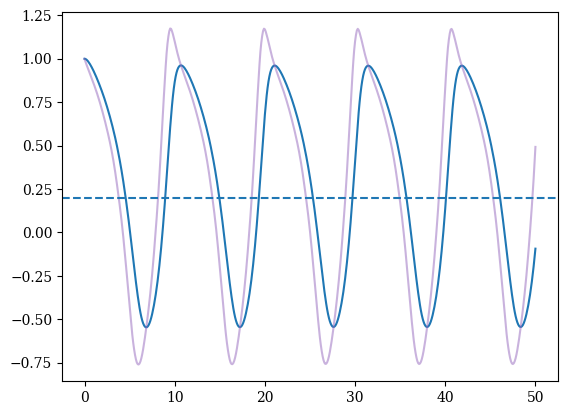

(-1.0, 1.0)

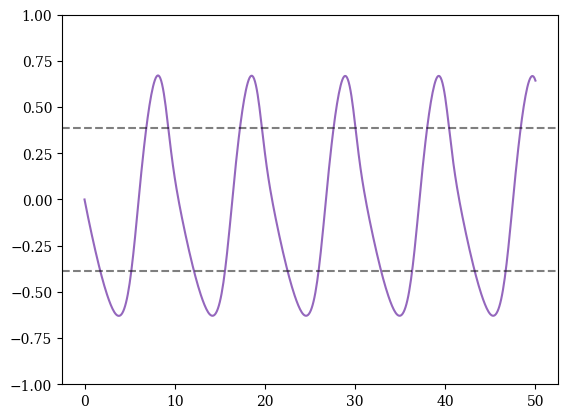

In [95]:

xu0 = np.array([-1,-1])
xu0 = np.array([1,0.0])
x_target = np.array(-0.2)
x_target = np.array(0.2)
t_max = 50
n_colloc = 501
eta=1e0
k=1


sol = sp_solve_ivp(
    hysteresis_ode_control,
    t_span=[0,t_max],
    y0=xu0,
    t_eval=np.linspace(0,t_max,n_colloc),
    args = (x_target,eta,k)
)


ui = sol.y[1,:]

xi_scaled_tensor = torch.tensor(scaler.transform(x_target.reshape(-1,1)),dtype=torch.float32).expand(n_colloc,1)
xi_scaled_tensor = torch.tensor(scaler.transform(sol.y[0,:].reshape(-1,1)),dtype=torch.float32)
ui_tensor = torch.tensor(ui.reshape(-1,1), dtype=torch.float32)

with torch.no_grad():
    gi = g(xi_scaled_tensor, ui_tensor)

gi_unscaled = scaler.inverse_transform(gi).reshape(-1)

Ts.append(sol.t)
Xs.append(sol.y[0,:])
Gs.append(gi_unscaled)
Us.append(sol.y[1,:])

plt.plot(sol.t,sol.y[0,:],c='tab:blue')
plt.plot(sol.t,gi_unscaled,c='tab:purple',alpha=0.5)
plt.axhline(x_target,linestyle='--',c='tab:blue')
# plt.ylim(-2,2)
plt.show()
plt.plot(sol.t,sol.y[1,:],c='tab:purple')
plt.axhline(np.sqrt(4/27),c='black',linestyle='--',alpha=0.5)
plt.axhline(-np.sqrt(4/27),c='black',linestyle='--',alpha=0.5)
plt.ylim(-1,1)

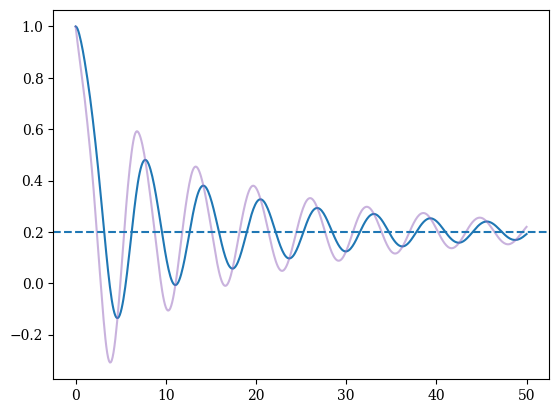

(-1.0, 1.0)

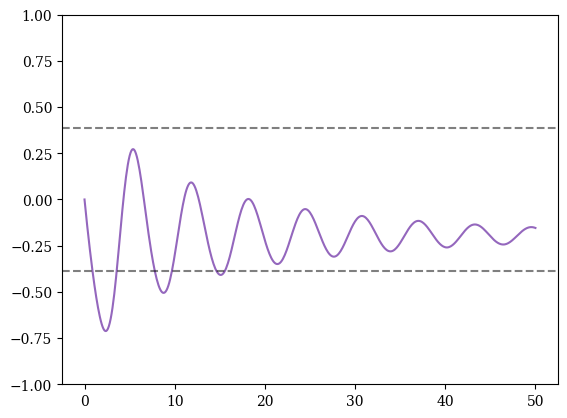

In [96]:

xu0 = np.array([-1,-1])
xu0 = np.array([1,0.0])
x_target = np.array(-0.2)
x_target = np.array(0.2)
t_max = 50
n_colloc = 501
eta=2e0
k=1


sol = sp_solve_ivp(
    hysteresis_ode_control,
    t_span=[0,t_max],
    y0=xu0,
    t_eval=np.linspace(0,t_max,n_colloc),
    args = (x_target,eta,k)
)


ui = sol.y[1,:]

xi_scaled_tensor = torch.tensor(scaler.transform(x_target.reshape(-1,1)),dtype=torch.float32).expand(n_colloc,1)
xi_scaled_tensor = torch.tensor(scaler.transform(sol.y[0,:].reshape(-1,1)),dtype=torch.float32)
ui_tensor = torch.tensor(ui.reshape(-1,1), dtype=torch.float32)

with torch.no_grad():
    gi = g(xi_scaled_tensor, ui_tensor)

gi_unscaled = scaler.inverse_transform(gi).reshape(-1)

Ts.append(sol.t)
Xs.append(sol.y[0,:])
Gs.append(gi_unscaled)
Us.append(sol.y[1,:])

plt.plot(sol.t,sol.y[0,:],c='tab:blue')
plt.plot(sol.t,gi_unscaled,c='tab:purple',alpha=0.5)
plt.axhline(x_target,linestyle='--',c='tab:blue')
# plt.ylim(-2,2)
plt.show()
plt.plot(sol.t,sol.y[1,:],c='tab:purple')
plt.axhline(np.sqrt(4/27),c='black',linestyle='--',alpha=0.5)
plt.axhline(-np.sqrt(4/27),c='black',linestyle='--',alpha=0.5)
plt.ylim(-1,1)

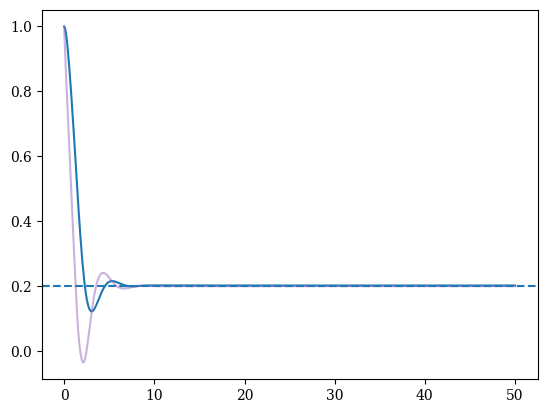

(-1.0, 1.0)

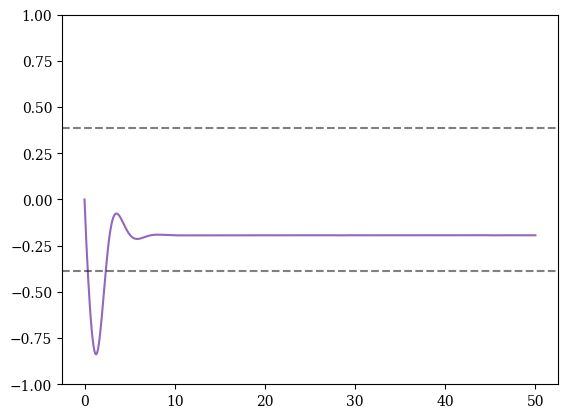

In [97]:

xu0 = np.array([-1,-1])
xu0 = np.array([1,0.0])
x_target = np.array(-0.2)
x_target = np.array(0.2)
t_max = 50
n_colloc = 501
eta=5e0
k=1


sol = sp_solve_ivp(
    hysteresis_ode_control,
    t_span=[0,t_max],
    y0=xu0,
    t_eval=np.linspace(0,t_max,n_colloc),
    args = (x_target,eta,k)
)


ui = sol.y[1,:]

xi_scaled_tensor = torch.tensor(scaler.transform(x_target.reshape(-1,1)),dtype=torch.float32).expand(n_colloc,1)
xi_scaled_tensor = torch.tensor(scaler.transform(sol.y[0,:].reshape(-1,1)),dtype=torch.float32)
ui_tensor = torch.tensor(ui.reshape(-1,1), dtype=torch.float32)

with torch.no_grad():
    gi = g(xi_scaled_tensor, ui_tensor)

gi_unscaled = scaler.inverse_transform(gi).reshape(-1)

Ts.append(sol.t)
Xs.append(sol.y[0,:])
Gs.append(gi_unscaled)
Us.append(sol.y[1,:])

plt.plot(sol.t,sol.y[0,:],c='tab:blue')
plt.plot(sol.t,gi_unscaled,c='tab:purple',alpha=0.5)
plt.axhline(x_target,linestyle='--',c='tab:blue')
# plt.ylim(-2,2)
plt.show()
plt.plot(sol.t,sol.y[1,:],c='tab:purple')
plt.axhline(np.sqrt(4/27),c='black',linestyle='--',alpha=0.5)
plt.axhline(-np.sqrt(4/27),c='black',linestyle='--',alpha=0.5)
plt.ylim(-1,1)

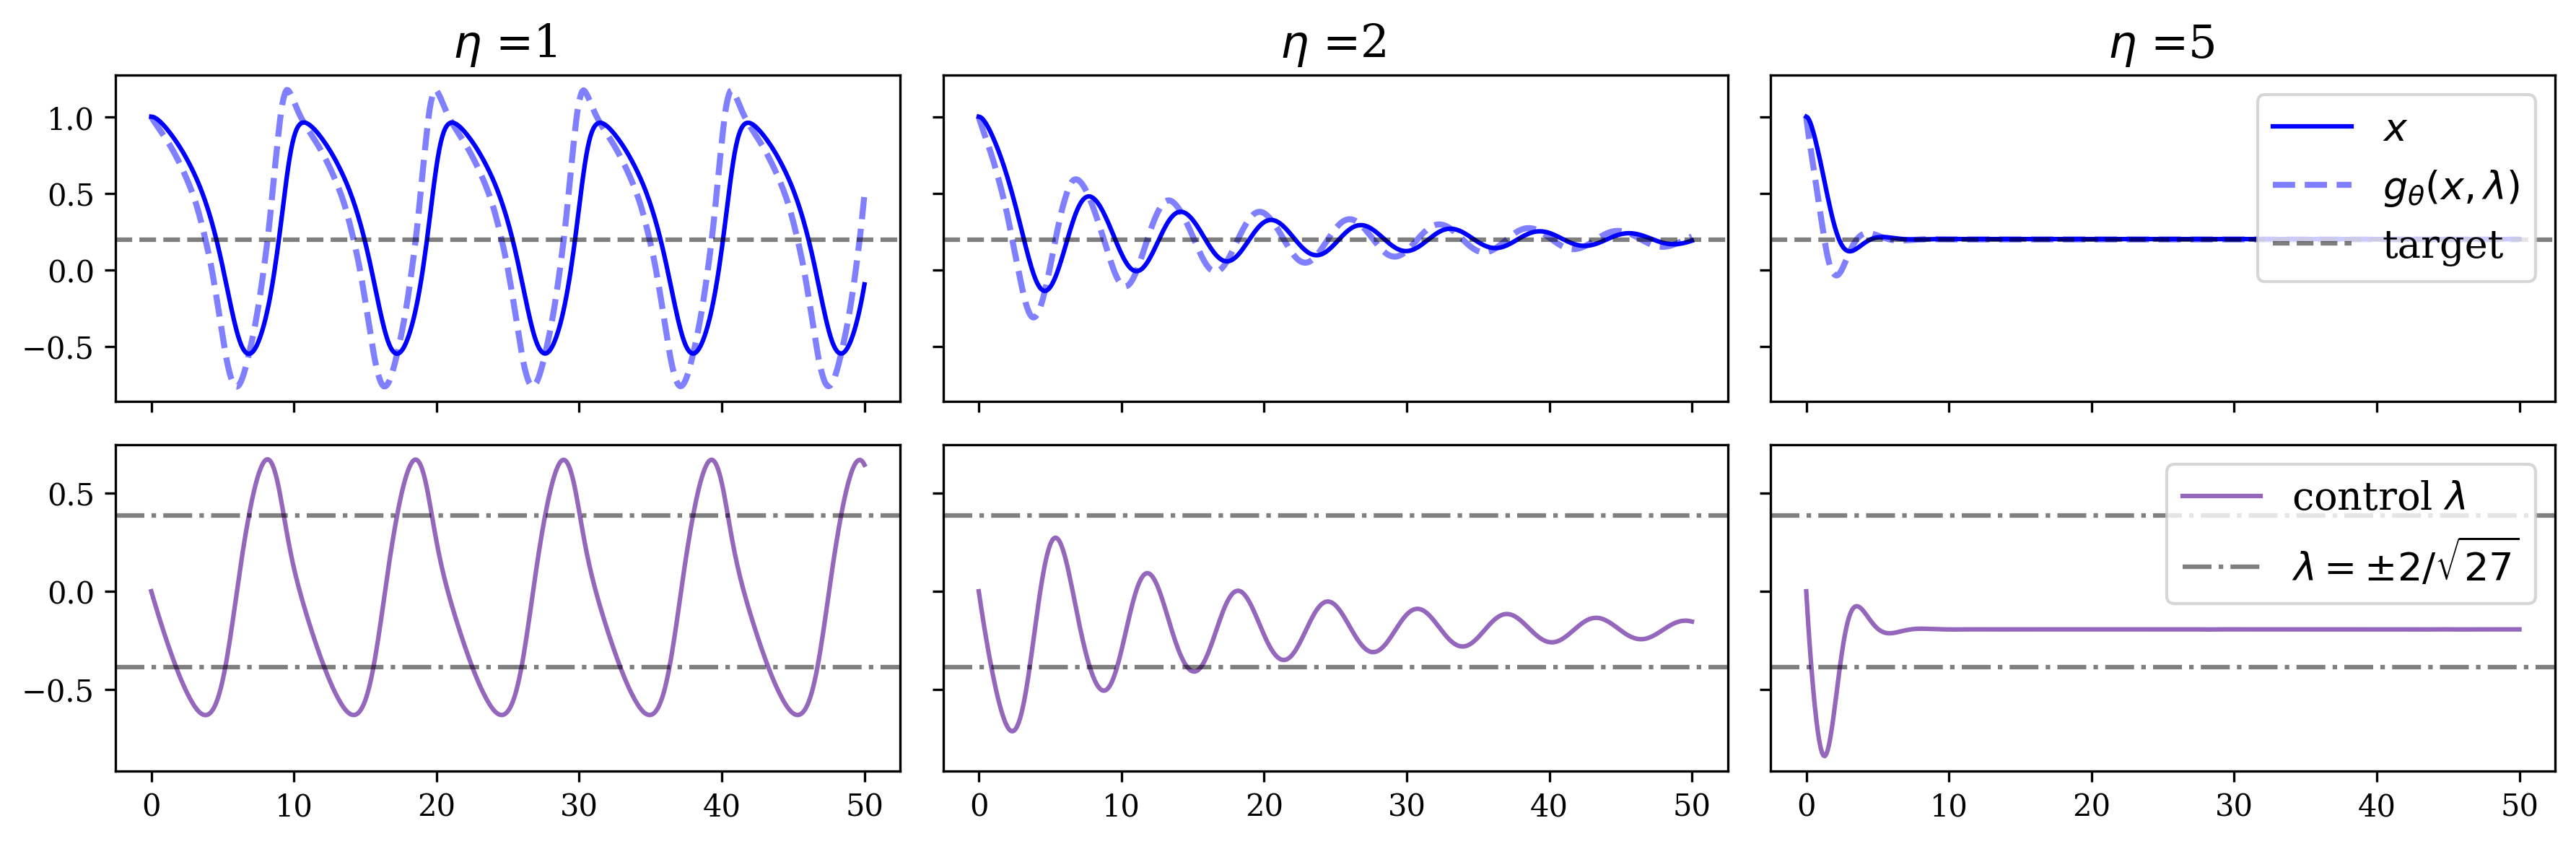

In [99]:
fig, axs = plt.subplots(2,3,figsize=(12,4),sharey='row',sharex=True,dpi=300)

alpha= 0.5
lw=2
axs = axs.flatten()

ax = axs[0]
ax.plot(Ts[0],Xs[0],c='blue',)
ax.plot(Ts[0],Gs[0],c='blue',linestyle='--',alpha=alpha,lw=lw)
ax.axhline(x_target, c='black',alpha=0.5, linestyle="--")
ax.set_title(rf"$\eta$ ={1} ",fontsize=15)


ax = axs[1]
ax.plot(Ts[1],Xs[1],c='blue',label=r"$x$")
ax.plot(Ts[1],Gs[1],c='blue',alpha=alpha,linestyle='--',lw=lw)
ax.axhline(x_target, c='black',alpha=0.5, linestyle="--",label=f"target = {0.2}")
ax.set_title(rf"$\eta$ ={2} ",fontsize=15)



i= 2
ax = axs[2]
ax.plot(Ts[2],Xs[2],c='blue',label=r"$x$")
ax.plot(Ts[2],Gs[2],c='blue',linestyle="--",alpha=alpha,label=r"$g_{\theta}(x,\lambda)$",lw=lw)
ax.axhline(x_target, c='black',alpha=0.5, linestyle="--",label=f"target")
ax.set_title(rf"$\eta$ ={5} ",fontsize=15)
ax.legend(loc="upper right",fontsize=13)


ax = axs[3]
ax.plot(Ts[0],Us[0],c="tab:purple")
ax.axhline(np.sqrt(4/27),c='black',linestyle='-.',alpha=alpha)
ax.axhline(-np.sqrt(4/27),c='black',linestyle='-.',alpha=alpha)


ax = axs[4]
ax.plot(Ts[1],Us[1],c="tab:purple",)
ax.axhline(np.sqrt(4/27),c='black',linestyle='-.',alpha=alpha)
ax.axhline(-np.sqrt(4/27),c='black',linestyle='-.',alpha=alpha)


ax = axs[5]
ax.plot(Ts[2],Us[2],c="tab:purple",label=r"control $\lambda$")
ax.axhline(np.sqrt(4/27),c='black',linestyle='-.',alpha=alpha,label=r"$\lambda = \pm 2/\sqrt{27}$")
ax.axhline(-np.sqrt(4/27),c='black',linestyle='-.',alpha=alpha)
ax.legend(loc="upper right",fontsize=13)


plt.tight_layout()
plt.savefig("eta_effects.png")
plt.show()